In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

Рассмотрим модель одномерной линейной регрессии *без свободного параметра* $y(x) = \theta x$, где $x\in \mathbb{R}$ и $\theta \in \mathbb{R}$. Предполагаем, что данные получены по правилу
$$Y_i = \theta x_i + \varepsilon_i,$$
где $i \in \{1, ..., n\}$, числа $x_i \in \mathbb{R}$ неслучайны, а $\varepsilon_i$ &mdash; случайные ошибки.

**1.** Посчитайте оценку $\widehat{\theta}$ методом наименьших квадратов по явной формуле.

**2.** Выпишите формулы итераций градиентного спуска (GD) и стохастического градиентного спуска (SGD) для поиска $\widehat{\theta}$. Не забудьте указать, как в SGD математически определяется батч (набор объектов на каждой итерации).

**3.** Опишите, что произойдет, если для некоторого $i$ ошибка $\varepsilon_i$ будет очень большой.


**Решение:**

1. Квадратичная ошибка:
$$
S(\theta) = \sum_{i=1}^{n} (Y_i - \theta x_i)^2
$$
Чтобы минимизировать ошибку можно взять производную и приравнять к нулю:
$$
\frac{d}{d\theta} \sum_{i=1}^{n} (y_i - \widehat{\theta} x_i)^2 = 0
$$
$$
\sum_{i=1}^{n} 2 (y_i - \widehat{\theta} x_i)(-x_i) = 0
$$
$$
\sum_{i=1}^{n} x_i y_i - \widehat{\theta} \sum_{i=1}^{n} x_i^2 = 0
$$
Отсюда можно выразить $\widehat{\theta}$:
$$
\widehat{\theta} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}
$$


2. Формула итерации GD ($\eta$ - шаг обучения):
$$
\theta_{k+1} = \theta_k - \eta \frac{\partial L(\theta_k)}{\partial \theta}
$$
Ошибка для GD:
$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \theta x_i)^2
$$
Ее градиент:
$$
\frac{\partial L(\theta)}{\partial \theta} = \frac{2}{n} \sum_{i=1}^{n} x_i (\theta x_i - y_i)
$$
Итоговая формула:
$$
\theta_{k+1} = \theta_k - \eta \frac{2}{n} \sum_{i=1}^{n} x_i (\theta_k x_i - y_i)
$$
Отличия для SGD: для GD когда считаем градиент используем все данные, а для SGD используем только небольшой батч объектов.
Ну коэффициенты для обычного градиентного спуска обновляются только после подсчета градиента на всей выборке, а для стохаотического - после подсчета градиента на очередном батче. (мы как будто перемешиваем выборку, потом делим ее на небольшие части, а потом идем на каждой части считаем градиент и обновляем коэффициенты.)
Пусть на текущей итерации $k$ мы выбрали батч $B_k$, состоящий из $m$ случайных примеров $(x_{i_1}, y_{i_1}), (x_{i_2}, y_{i_2}), \dots, (x_{i_m}, y_{i_m})$.
Определение батча. Пусть $(x_{i_1}, y_{i_1}), (x_{i_2}, y_{i_2}), \dots, (x_{i_n}, y_{i_n})$ - перемешанная выборка. Тогда батчем назовем $(x_{i_ml}, y_{i_ml}), (x_{i_ml+1}, y_{i_ml+1}), \dots, (x_{i_ml+m-1}, y_{i_ml+m-1})$ для какого-то натурального $l$, если $m$ - размер батча.
Формула итерации для SGD:
$$
\theta_{k+1} = \theta_k - \eta \cdot \frac{1}{m} \sum_{j=1}^{m} \frac{\partial L_{i_j}(\theta_k)}{\partial \theta}
$$
$$
L_{i_j}(\theta) = (y_{i_j} - \theta x_{i_j})^2
$$
$$
\frac{\partial L_{i_j}(\theta)}{\partial \theta} = 2 x_{i_j} (\theta x_{i_j} - y_{i_j})
$$
Итоговая формула для SGD:
$$
\theta_{k+1} = \theta_k - \eta \cdot \frac{2}{m} \sum_{j=1}^{m} x_{i_j} (\theta_k x_{i_j} - y_{i_j})
$$

3. Из формул выше явно видно, что градиент ошибки для каждой итерации напрямую зависит от значений $\varepsilon_i$. Это приведет к тому что, при слишком большом значении $\varepsilon_i$ шаг обновления будет очень большим. Такой выброс может привести к значительным колетаниям $\theta$ в процессе обучения. Эта проблема актуальна для обоих из разобранных методов, но в случае, если для подсчета градиента используется небольшой батч, то внутри него на каких-то шагах оценка $\theta$ может сильно сдвигаться в сторону этого выброса. Однако поскольку $\varepsilon_i$ попадет в довольно небольшое число батчей, то это будет не на всех шагах. А для обычного градиентного спуска оценка будет сдвигаться меньше за счет масштаба (просто больше данных), но зато на каждом шаге.


Рассмотрим датасет <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset">Bike Sharing Dataset</a> от компании <a target="_blank" href="https://www.capitalbikeshare.com/">Capital Bikeshare</a>, располагающей автоматизированными пунктами проката велосипедов. В датасете по дням записаны календарная информация и погодные условия, а также число прокатов в этот день. Цель &mdash; предсказать количество арендованных велосипедов по остальным характеристикам.

Будем работать только со следующими признаками:
* `season`: время года: 1 &mdash; зима, 2 &mdash; весна, 3 &mdash; лето, 4 &mdash; осень;
* `mnth`: месяц от 1 до 12;
* `holiday`: является ли текущий день праздничным;
* `weekday`: день недели от 0 до 6;
* `workingday`: является ли текущий день рабочим или выходным;
* `weathersit`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `temp`: температура в Цельсиях;
* `atemp`: температура по ощущениям в Цельсиях;
* `hum`: влажность воздуха;
* `windspeed`: скорость ветра;
* `cnt`: количество арендованных велосипедов в текущий день.

---

Скачайте, загрузите данные и разделите на обучающую и тестовую части в соотношении 4:1.

In [3]:
df = pd.read_excel("bike+sharing+dataset/day.xlsx")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
train, test = train_test_split(df, test_size=0.2, random_state=42)


#### 1. Визуальный анализ


В случае mnth значений довольно много, поэтому не очень понятно  к каким признакам его относить. Но арифметические операции в этом случае не имеют особого смысла. ИИ предложил способ с этим бороться, закодировать через $mnth_{sin} = \sin\left(\frac{2\pi \cdot mnth}{12}\right)$ и $mnth_{cos} = \cos\left(\frac{2\pi \cdot mnth}{12}\right)$ и арифметические операции выполнять как для углов. Тогда арифметические операции будут корректно работать. Но в условии не было задач как-то преобразовывать данные, поэтому я оставлю признак категориальным.

In [5]:
categorial_features = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
real_features = ["temp", "atemp", "hum", "windspeed"]
target_feature = "cnt"

In [ ]:
palette = sns.color_palette('inferno', n_colors=12)
sns.set_palette(palette) 
html_content = "<html><body>"
for hue in categorial_features:
    pair_grid = sns.PairGrid(
        train[["temp", "atemp", "hum", "windspeed", "cnt", hue]], 
        hue=hue, 
        diag_sharey=False, 
        height=3,
        palette=palette 
    )

    pair_grid.map_lower(sns.kdeplot, alpha=0.6)
    pair_grid.map_upper(plt.scatter, alpha=0.3)
    pair_grid.map_diag(
        sns.kdeplot, lw=3, alpha=0.6, common_norm=False
    )
    pair_grid.add_legend()

    img_filename = f"plot_{hue}.png"
    pair_grid.savefig(img_filename)

    html_content += f'<img src="{img_filename}" style="width:100%;"><br>'

html_content += "</body></html>"

with open("all_plots.html", "w", encoding="utf-8") as f:
    f.write(html_content)

**Выводы по графикам:**
1. Между temp и atemp есть явная линейная зависимость, можно оставить только один из них.
2. hum, windspeed почти не влияет на количество аренд (тоьлко при очень сильной влажности количество снижается, тут можно использовать индикатор).
3. Между cnt и temp есть некая зависимость, но она не очень линейная и не совсем просто определить ее характер (мне кажется, что корень или логарифм).
4. У температуры и сезонов (и месяцов) есть довольно четкая корреляция.
5. У месяцев и сезонов тоже (это вроде очевидно, но все же).
6. У cnt есть зависимость с сезонами (и месяцами), летом - максимум, зимой - минимум, но зависимость очень нелинейная и вообще непонятно, как ее оценивать :-(.
7. День недели почти не влияет на cnt, кроме разделения на рабочие и нерабочие дни. С workingday есть зависимость.
8. На графиках есть только один выброс, который однозначно определяется как выброс, где hum нулевой (он удалится при построении модели). Есть ещё несколько, но на мой взгляд не всегда понятно, это выбросы или границы скоплений точек.


Выполните предобработку данных


**Процедура предобработки данных:**

**a).** На графиках выбросы которые сильно видно только один в зависимости температур друг от друга и несколько с очень низкой влажностью. С тем, который касается температур я не буду ничего делать, а те, которые касаются влажности удалю (поставлю минимальную возможную влажность 20%).   
**б).** Стандартизирую температуру и скорость ветра.  
**в).** Введу признак $ln(temp)$.  
**г).** Логарифмирую cnt.  
**д).** Создам новый признак, который будет отыечать за комфорт погоды temp * hum.  
**е).** Оставлю только одну температру, потому что они линейно зависимы друг от друга.

In [7]:
train = train[train['hum'] >= 0.2]

test = test[test['hum'] >= 0.2]

In [8]:
scaler = StandardScaler()

train[['temp', 'atemp', 'windspeed']] = scaler.fit_transform(train[['temp', 'atemp', 'windspeed']])

test[['temp', 'atemp', 'windspeed']] = scaler.transform(test[['temp', 'atemp', 'windspeed']])

In [9]:
train['log_temp'] = np.log(train['temp'] - test['temp'].min() + 1)

test['log_temp'] = np.log(test['temp'] - test['temp'].min() + 1)

In [10]:
train['log_cnt'] = np.log(train['cnt'] + 1)

test['log_cnt'] = np.log(test['cnt'] + 1)

In [11]:
train['comfort'] = train['temp'] * train['hum']

test['comfort'] = test['temp'] * test['hum']


#### 3. Обучение модели и ее анализ

Обучите линейную регрессию из sklearn на полученных данных и посмотрите на полученные оценки коэффициентов.

In [12]:
X = train.drop(columns=['cnt', 'log_cnt', 'instant', 'dteday', 'mnth', 'yr', 'temp', 'atemp', 'casual', 'registered', 'cnt'])  
y = train['log_cnt'] 

In [13]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [14]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)
print("Свободный коэффициент:", model.intercept_)

      Feature  Coefficient
0      season     0.112829
1     holiday    -0.148521
2     weekday     0.009964
3  workingday     0.064884
4  weathersit    -0.117411
5         hum    -0.921121
6   windspeed    -0.064923
7    log_temp     1.404521
8     comfort    -0.265438
Свободный коэффициент: 7.140982344910926


Посчитайте ошибку предсказания на тестовой выборке по метрикам RMSE, MAE, MAPE.

In [15]:
test_filtered = test[test['cnt'] < test['cnt'].mean() + 3 * test['cnt'].std()] # я искючаю выбросы только по таргетному признаку

In [16]:
X_test = test_filtered.drop(columns=['cnt', 'log_cnt', 'instant', 'dteday', 'mnth', 'yr', 'temp', 'atemp', 'casual', 'registered', 'cnt'])  
y_test = test_filtered['log_cnt']

In [17]:
log_cnt_preds = model.predict(X_test)

In [18]:
scores = pd.DataFrame({
    "RMSE": np.sqrt(mean_squared_error(y_test, log_cnt_preds)),
    "MAE": mean_absolute_error(y_test, log_cnt_preds),
    "MAPE": mean_absolute_percentage_error(y_test, log_cnt_preds),
}, index=[0])
print(scores)

       RMSE       MAE      MAPE
0  0.524819  0.305246  0.044244


Это ошибки для log_cnt. Вообще я работаю с ним, как с таргетным признаком, поэтому дальше все ошибки будут для него.

In [19]:
mr = np.linalg.inv(X.T @ X) @ X.T @ y

In [20]:
mr = mr.to_numpy() 
mr = mr.reshape(-1, 1)

In [21]:
predictions = X_test @ mr

In [22]:
scores = pd.DataFrame({
    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    "MAE": mean_absolute_error(y_test, predictions),
    "MAPE": mean_absolute_percentage_error(y_test, predictions),
}, index=[0])

print(scores)

       RMSE       MAE     MAPE
0  0.953585  0.609641  0.08462


Попробуйте посчитать оценку коэффициентов с помощью формулы, полученной на занятии.  
$
\hat{\theta} = (X^T X)^{-1} X^T y - формула
$  
Наверное от того, что много зависимых признаков будут проблемы. Я пока оставлю в признаках вообще все возможное.

In [23]:
X = train.drop(columns=['dteday'])
X_test = test_filtered.drop(columns=['dteday'])

In [24]:
print (X.columns)

Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt', 'log_temp', 'log_cnt', 'comfort'],
      dtype='object')


In [25]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [26]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)
print("Свободный коэффициент:", model.intercept_)

       Feature   Coefficient
0      instant -2.120346e-18
1       season -1.235990e-17
2           yr  1.590590e-15
3         mnth  1.389385e-16
4      holiday  2.827937e-18
5      weekday -5.278331e-18
6   workingday -3.142198e-18
7   weathersit -4.512981e-16
8         temp -2.052395e-16
9        atemp  4.694918e-17
10         hum  6.242495e-16
11   windspeed  2.631810e-17
12      casual -6.295107e-14
13  registered -6.295108e-14
14         cnt  6.295138e-14
15    log_temp  9.753836e-16
16     log_cnt  1.000000e+00
17     comfort -1.542632e-16
Свободный коэффициент: 1.0658141036401503e-14


In [27]:
mr = np.linalg.inv(X.T @ X) @ X.T @ y

mr = mr.to_numpy() 
mr = mr.reshape(-1, 1)

predictions = X_test @ mr

In [28]:
scores = pd.DataFrame({
    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
    "MAE": mean_absolute_error(y_test, predictions),
    "MAPE": mean_absolute_percentage_error(y_test, predictions),
}, index=[0])

print(scores)

         RMSE         MAE       MAPE
0  138.014914  115.485808  14.417485


Если честно, я много раз пока строила меняла всего, в самом начале у меня получилось Nan в Mape, потом я долго пыталась исправить и сейчас уже не моу вспомнить, что я делаю не так :(. Идейно видно, что ошибки очень сильно возрастают. Полученные значения для log_cnt это безумно большие ошибки. Поэтому можно считать, что они почти бесконечные. Коэффициенты при этом становятся очень сильно маленькими.

**Выводы:**

1. При вычислении коэффициентов линейной регрессии по фомуле с занятия очень важно следить за независимостью признаков, иначе модель окажется очень плохой.
2. Точности в задаче получились не очень высокими. Значит данные изначально были обработаны не очень хорошо или конкретный набор плохо подходит для построения линейной регрессии.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2c0205cf5ab3ec02c6ea667faa01e48b -->
---
### Задача 3.

Одно из интересных свойств модели логистической регрессии — при соблюдении её предположений она дает возможность получать несмещенные оценки вероятностей принадлежности объекта к определенному классу. Проверим это на конкретном примере.

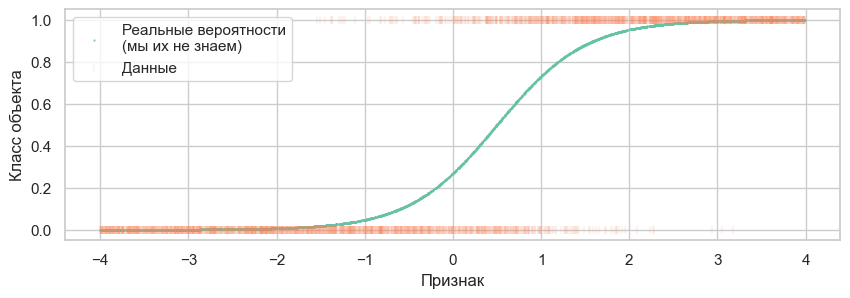

In [23]:
sample_size = 3000  # Размер выборки

# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Обучите логистическую регрессию, используя реализацию из sklearn.

In [24]:
model = LogisticRegression(penalty=None)
model.fit(X, y)

LogisticRegression(penalty=None)

In [25]:
X_range = np.linspace(X.min() - 1, X.max() + 1, 500).reshape(-1, 1)
probabilities = model.predict_proba(X_range)[:, 1]

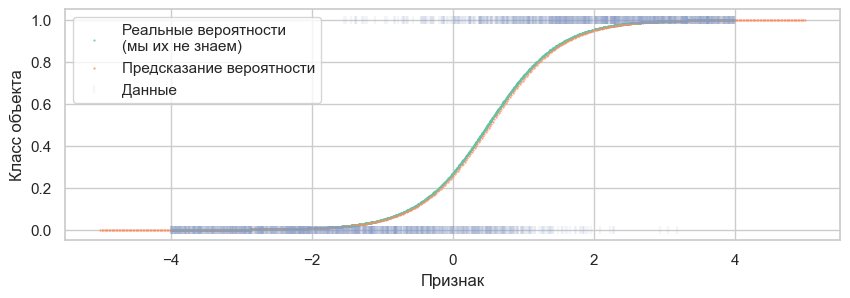

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X_range, probabilities, marker =".", s=1, label="Предсказание вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()
plt.show()

In [27]:
print("Коэффициент:", model.coef_)
print("Свободный коэффициент:", model.intercept_)

Коэффициент: [[1.99196055]]
Свободный коэффициент: [-1.06991114]


Постройте:  предсказания классов, предсказания вероятностей класса 1.

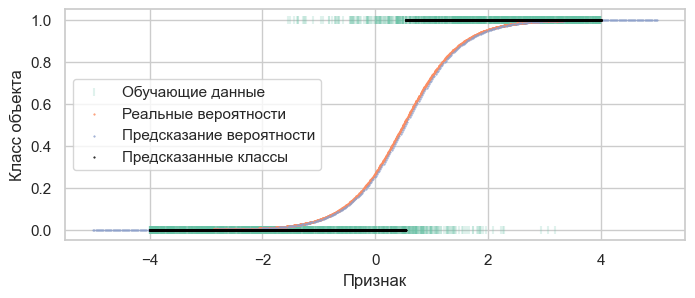

In [28]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))

y_pred_classes = model.predict(X_grid)
y_pred_probs = model.predict_proba(X_grid)[:, 1]

plt.figure(figsize=(8, 3))
plt.scatter(X, y, marker="|", alpha=0.2, label="Обучающие данные")
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X_range, probabilities, marker =".", s=1, label="Предсказание вероятности")
plt.scatter(X_grid, y_pred_classes, marker =".", s=1, label="Предсказанные классы", color="black")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()
plt.show()

Разбейте отрезок  [−4, 4] на одинаковые бины длины длины 0.2 и посчитайте в каждом бине долю объектов класса 1.

In [29]:
bins = np.arange(-4, 4, 0.2)
bin_indices = np.digitize(X.ravel(), bins)

df = pd.DataFrame({"X": X.ravel(), "y": y, "bin": bin_indices})

bin_avg = df.groupby("bin")["y"].mean()

bin_avg = bin_avg.reindex(range(1, len(bins)), fill_value=0)

bin_centers = bins[:-1] + 0.1

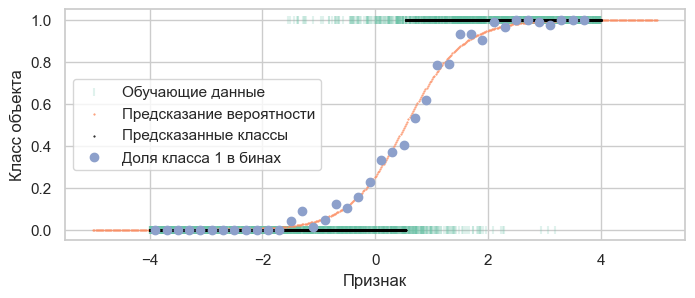

In [30]:
plt.figure(figsize=(8, 3))
plt.scatter(X, y, marker="|", alpha=0.2, label="Обучающие данные")
plt.scatter(X_range, probabilities, marker =".", s=1, label="Предсказание вероятности")
plt.scatter(X_grid, y_pred_classes, marker =".", s=1, label="Предсказанные классы", color="black")
plt.scatter(bin_centers, bin_avg, label="Доля класса 1 в бинах")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()
plt.show()

Бины довольно неплохо отражают реальную ситуацию, тк довольно близко к линиям предсказанных и реальных вероятностей.

Повторите проведенное исследование для следующих данных и сравните результаты.

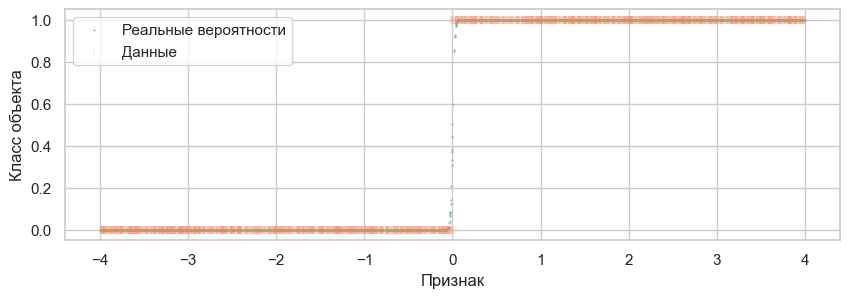

In [31]:
# Признаки
X = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X.ravel()))
y = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X, y, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

In [32]:
model = LogisticRegression(penalty=None)
model.fit(X, y)

LogisticRegression(penalty=None)

In [33]:
X_range = np.linspace(X.min() - 1, X.max() + 1, 500).reshape(-1, 1)
probabilities = model.predict_proba(X_range)[:, 1]

In [34]:
X_grid = np.linspace(-4, 4, 10000).reshape((-1, 1))

y_pred_classes = model.predict(X_grid)
y_pred_probs = model.predict_proba(X_grid)[:, 1]

In [35]:
bins = np.arange(-4, 4, 0.2)
bin_indices = np.digitize(X.ravel(), bins)

df = pd.DataFrame({"X": X.ravel(), "y": y, "bin": bin_indices})

bin_avg = df.groupby("bin")["y"].mean()

bin_avg = bin_avg.reindex(range(1, len(bins)), fill_value=0)

bin_centers = bins[:-1] + 0.1

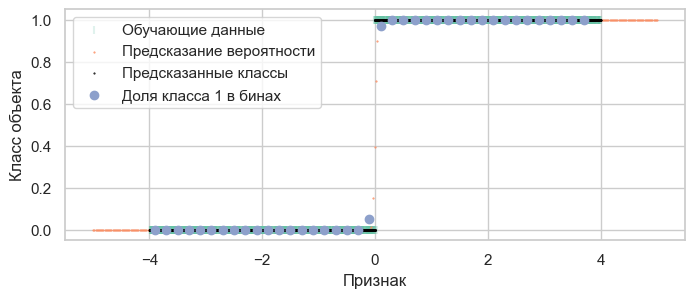

In [36]:
plt.figure(figsize=(8, 3))
plt.scatter(X, y, marker="|", alpha=0.2, label="Обучающие данные")
plt.scatter(X_range, probabilities, marker =".", s=1, label="Предсказание вероятности")
plt.scatter(X_grid, y_pred_classes, marker =".", s=1, label="Предсказанные классы", color="black")
plt.scatter(bin_centers, bin_avg, label="Доля класса 1 в бинах")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend()
plt.show()

**Выводы:**
1. Для обоих классов предсказанные вероятности и реальные очень неплохо совпадают (значит модели обучились хорошо).
2. Также предсказанные вероятности неплохо совпадают с долями классов (точки на графиках).
3. Если сравнивать разные наборы данных, то видно, что для второго предсказания будут лучше, так как классы более разделены. На первом наборе данныъ есть участки, где все будет очень неточно работать, а на втором такого участка практически нет.

---


Продолжим исследовать модель логистической регрессии.  Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета.

In [34]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data.head()

,feature_1,feature_2,target
0,0,1,0
1,1,0,1
2,0,1,0
3,1,0,1
4,0,1,0


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания. Исследуем, как с этим справляется логистическая регрессия.


Посчитайте долю класса 1 для каждой категории объектов.

In [35]:
pivot = data.pivot_table(values="target", index=["feature_1", "feature_2"], aggfunc="mean")
print(pivot)

                       target
feature_1 feature_2          
0         0          0.730000
          1          0.017940
1         0          0.652542
          1          0.365440


Обучите логистическую регрессию.

In [36]:
model = LogisticRegression(penalty=None)  
model.fit(data[["feature_1", "feature_2"]], data["target"])

LogisticRegression(penalty=None)

In [37]:
data["predicted_proba"] = model.predict_proba(data[["feature_1", "feature_2"]])[:, 1]

In [38]:
comparison = data.pivot_table(values=["target", "predicted_proba"], index=["feature_1", "feature_2"], aggfunc="mean")
print(comparison)

                     predicted_proba    target
feature_1 feature_2                           
0         0                 0.633150  0.730000
          1                 0.157431  0.017940
1         0                 0.780636  0.652542
          1                 0.278113  0.365440


Здесь модель выдает смещенные оценки вероятности.


Почему результаты не совпадают?


$P(y = 1 \mid X) = f(w_0 + w_1 x_1 + w_2 x_2)$

где,  
$f(z) = \frac{1}{1 + e^{-z}}$,  
$w_0$ - свободный коэффициент,  
$w_1, w_2$ - коэффициенты для признаков,  
$P(y = 1 \mid X)$ - предсказанная вероятность.

Модель делает такое предположение: $\log \frac{P(y=1)}{P(y=0)} = w_0 + w_1 x_1 + w_2 x_2$. То есть зависимость от признаков предполагается линейная.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 1180c36f8ac39574c944b19ddee07271 -->
Предложите и реализуйте способ построения модели логистической регрессии так, чтобы она точнее предсказывала частоты, посчитанные ранее.

Я попробую добавить признаки, которые помогут немного сгладить нелинейность зависимости. Для начала остановлюсь на признаках второй степени.

In [39]:
data['feature_1_squared'] = data['feature_1'] ** 2
data['feature_2_squared'] = data['feature_2'] ** 2
data['feature_1_x_feature_2'] = data['feature_1'] * data['feature_2']

In [40]:
model = LogisticRegression(penalty=None)
model.fit(data[['feature_1', 'feature_2', 'feature_1_squared', 'feature_2_squared', 'feature_1_x_feature_2']], data["target"])

LogisticRegression(penalty=None)

In [41]:
data["predicted_proba_2"] = model.predict_proba(data[['feature_1', 'feature_2', 'feature_1_squared', 'feature_2_squared', 'feature_1_x_feature_2']])[:, 1]

In [42]:
comparison = data.pivot_table(values=["target", "predicted_proba", "predicted_proba_2"], index=["feature_1", "feature_2"], aggfunc="mean")
print(comparison)

                     predicted_proba  predicted_proba_2    target
feature_1 feature_2                                              
0         0                 0.633150           0.729964  0.730000
          1                 0.157431           0.017937  0.017940
1         0                 0.780636           0.652563  0.652542
          1                 0.278113           0.365487  0.365440


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3f951c224a4ac471c658ed7755ff9521 -->
**Выводы:**
У логической регресии есть проблема, сосотоящая в том, что как будто нужно "угадать" функцию, которую подставляем. Ее можно попробовать решить, приближая функцию, например многочленами. В таком случае точность должна возрасти (как получилось в задаче). Улучшенная модель во втором случае даёт практически несмещённые оценки вероятностей, а в первой версии модели десть смещение.